<a href="https://colab.research.google.com/github/Tiger-I-Yang/Week4-NeuralNetworks/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

load precomputed features and emotions for the two datasets

In [2]:
ravdess_features = pd.read_csv('featuresRavdess.csv', index_col = 0)
ravdess_emotions = pd.read_csv('emotionsRavdess.csv', index_col = 0)

tiger_features = pd.read_csv('featuresCustom.csv', index_col = 0)
tiger_emotions = pd.read_csv('emotionsCustom.csv', index_col = 0)

check

In [7]:
print(ravdess_features.shape)
print(ravdess_emotions.shape)
print()
print(tiger_features.shape)
print(tiger_emotions.shape)

(1439, 180)
(1439, 1)

(16, 180)
(16, 1)


define function to print features

In [9]:
def print_features(df):
    # Check chromagram feature values
    features_df_chromagram = df.iloc[:,:11]
    chroma_min = features_df_chromagram.min().min()
    chroma_max = features_df_chromagram.max().max()
    # stack all features into a single series so we don't get a mean of means or stdev of stdevs
    chroma_mean = features_df_chromagram.stack().mean()
    chroma_stdev = features_df_chromagram.stack().std()
    print(f'12 Chromagram features:       \
    min = {chroma_min:.3f}, \
    max = {chroma_max:.3f}, \
    mean = {chroma_mean:.3f}, \
    deviation = {chroma_stdev:.3f}')

    # Check mel spectrogram feature values
    features_df_melspectrogram = df.iloc[:,12:139]
    mel_min = features_df_melspectrogram.min().min()
    mel_max = features_df_melspectrogram.max().max()
    # stack all features into a single series so we don't get a mean of means or stdev of stdevs
    mel_mean = features_df_melspectrogram.stack().mean()
    mel_stdev = features_df_melspectrogram.stack().std()
    print(f'\n128 Mel Spectrogram features: \
    min = {mel_min:.3f}, \
    max = {mel_max:.3f}, \
    mean = {mel_mean:.3f}, \
    deviation = {mel_stdev:.3f}')

    # Check MFCC feature values
    features_df_mfcc = df.iloc[:,140:179]
    mfcc_min = features_df_mfcc.min().min()
    mfcc_max = features_df_mfcc.max().max()
    # stack all features into a single series so we don't get a mean of means or stdev of stdevs
    mfcc_mean = features_df_mfcc.stack().mean()
    mfcc_stdev = features_df_mfcc.stack().std()
    print(f'\n40 MFCC features:             \
    min = {mfcc_min:.3f},\
    max = {mfcc_max:.3f},\
    mean = {mfcc_mean:.3f},\
    deviation = {mfcc_stdev:.3f}')

use it on both datasets

In [12]:
print('\nravdess\n')
print_features(ravdess_features)

print('\ntiger\n')
print_features(tiger_features)


ravdess

12 Chromagram features:           min = 0.310,     max = 1.000,     mean = 0.667,     deviation = 0.088

128 Mel Spectrogram features:     min = 0.000,     max = 149.208,     mean = 0.188,     deviation = 1.604

40 MFCC features:                 min = -1131.371,    max = 115.126,    mean = -15.073,    deviation = 100.101

tiger

12 Chromagram features:           min = 0.496,     max = 0.787,     mean = 0.639,     deviation = 0.061

128 Mel Spectrogram features:     min = 0.000,     max = 3.901,     mean = 0.096,     deviation = 0.326

40 MFCC features:                 min = -600.107,    max = 145.301,    mean = -9.753,    deviation = 86.508


import the two scalers

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

standard_scaler = StandardScaler()

minmax_scaler = MinMaxScaler()

create scaled versions of both datasets

In [18]:
ravdess_features_standard_scaled = pd.DataFrame(
  standard_scaler.fit_transform(ravdess_features)
)
tiger_features_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(tiger_features)
)
ravdess_features_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(ravdess_features)
)
tiger_features_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(tiger_features)
)

verify scaling

In [21]:
print('\nravdess\n')
print_features(ravdess_features)
print('\nravdess standard scaled\n')
print_features(ravdess_features_standard_scaled)
print('\nravdess minmax scaled\n')
print_features(ravdess_features_minmax_scaled)

print('\n\ntiger\n')
print_features(tiger_features)
print('\ntiger stardard scaled\n')
print_features(tiger_features_standard_scaled)
print('\ntiger minmax scaled\n')
print_features(tiger_features_minmax_scaled)


ravdess

12 Chromagram features:           min = 0.310,     max = 1.000,     mean = 0.667,     deviation = 0.088

128 Mel Spectrogram features:     min = 0.000,     max = 149.208,     mean = 0.188,     deviation = 1.604

40 MFCC features:                 min = -1131.371,    max = 115.126,    mean = -15.073,    deviation = 100.101

ravdess standard scaled

12 Chromagram features:           min = -3.896,     max = 4.368,     mean = -0.000,     deviation = 1.000

128 Mel Spectrogram features:     min = -0.474,     max = 36.531,     mean = 0.000,     deviation = 1.000

40 MFCC features:                 min = -4.803,    max = 6.238,    mean = 0.000,    deviation = 1.000

ravdess minmax scaled

12 Chromagram features:           min = 0.000,     max = 1.000,     mean = 0.478,     deviation = 0.145

128 Mel Spectrogram features:     min = 0.000,     max = 1.000,     mean = 0.014,     deviation = 0.060

40 MFCC features:                 min = 0.000,    max = 1.000,    mean = 0.413,    deviatio

because we've already ascertained the model's ideal hyperparameters and shape with the grid search in the tutorial notebook, i think its fine for me to continue using those and do a regular train-test split and skip validating entirely here.

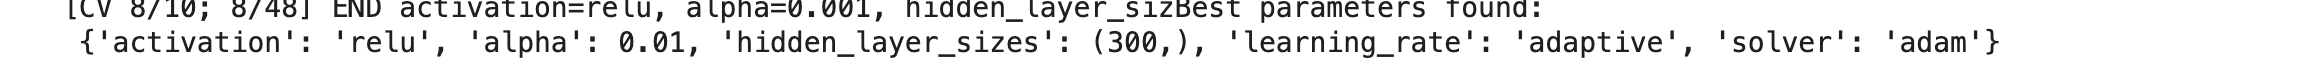

In [22]:
from sklearn.model_selection import train_test_split

ravdess_features_train, ravdess_features_test, ravdess_emotions_train, ravdess_emotions_test = train_test_split(
    ravdess_features,
    ravdess_emotions,
    test_size=0.2,
    random_state=42
)

ravdess_features_standard_scaled_train, ravdess_features_standard_scaled_test, _, _ = train_test_split(
    ravdess_features_standard_scaled,
    ravdess_emotions,
    test_size=0.2,
    random_state=42
)

ravdess_features_minmax_scaled_train, ravdess_features_minmax_scaled_test, _, _ = train_test_split(
    ravdess_features_minmax_scaled,
    ravdess_emotions,
    test_size=0.2,
    random_state=42
)

setup MLP classifier

In [44]:
from sklearn.neural_network import MLPClassifier

# Now we know best parameters from the Hyperparameter tuning
# We can use them for the final model
model = MLPClassifier(
    activation='relu',
    solver='adam',
    alpha=0.01,
    batch_size=256,
    hidden_layer_sizes=(300,),
    learning_rate='adaptive',
    max_iter=1000, # I've found for this task, loss converges at ~1000 iterations
    random_state=42,
)

train, test, and plot

ravdess unscaled 


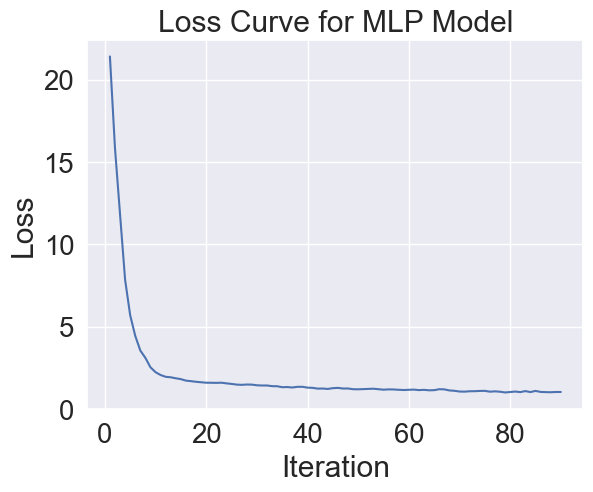

---------------------------------- training set:
Accuracy =  65.334%
Precision =  67.084%
Recall =  62.697%
F-score =  62.1%
----------------------------------------
Best performing emotion:  FEARFUL (82.35% accuracy)
Worst performing emotion: NEUTRAL (16.25% accuracy)
----------------------------------------


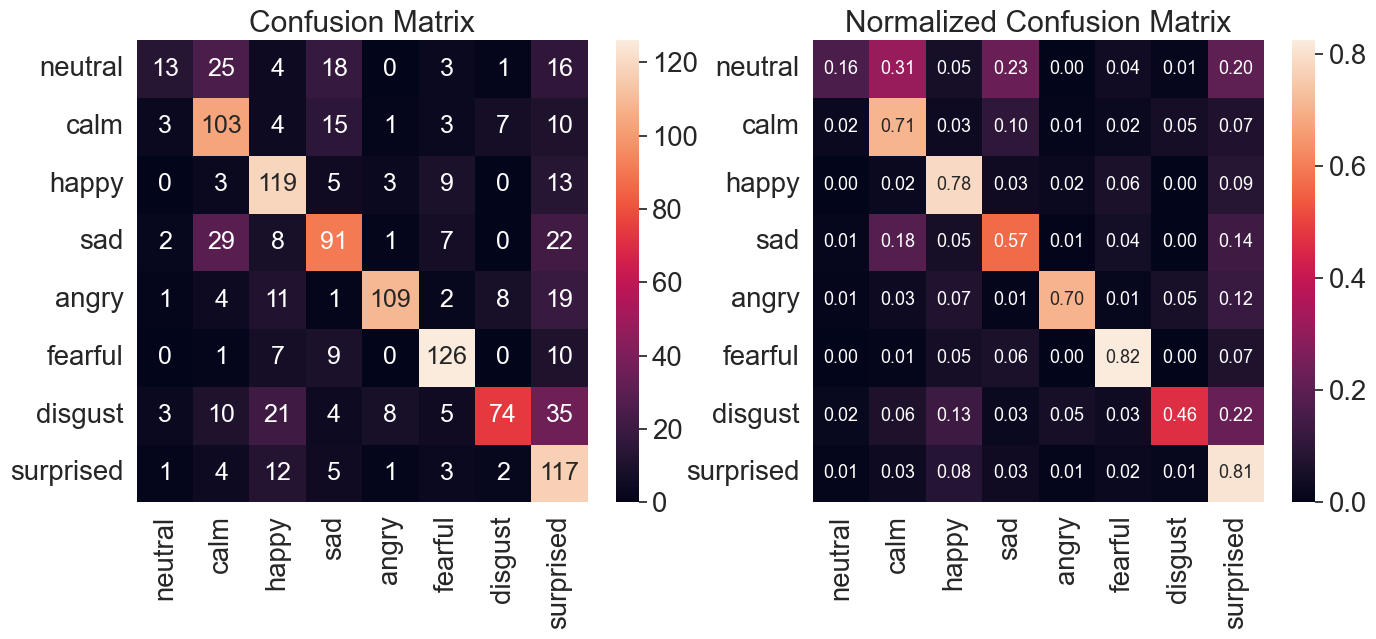

---------------------------------- test set:
Accuracy =  57.292%
Precision =  57.335%
Recall =  53.094%
F-score =  53.7%
----------------------------------------
Best performing emotion:  SURPRISED (78.26% accuracy)
Worst performing emotion: NEUTRAL (12.50% accuracy)
----------------------------------------


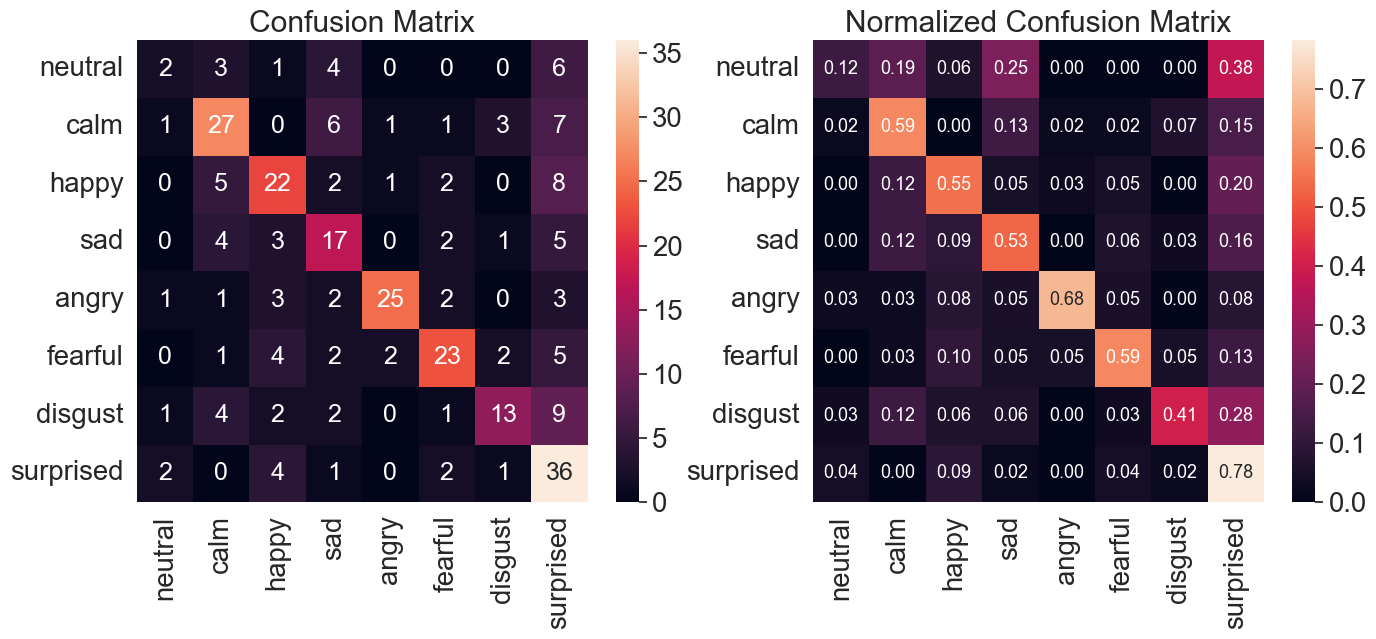

---------------------------------- tigers set:
Accuracy =  18.750%
Precision =  14.423%
Recall =  18.750%
F-score =  11.7%
----------------------------------------
Best performing emotion:  CALM (100.00% accuracy)
Worst performing emotion: NEUTRAL (0.00% accuracy)
----------------------------------------


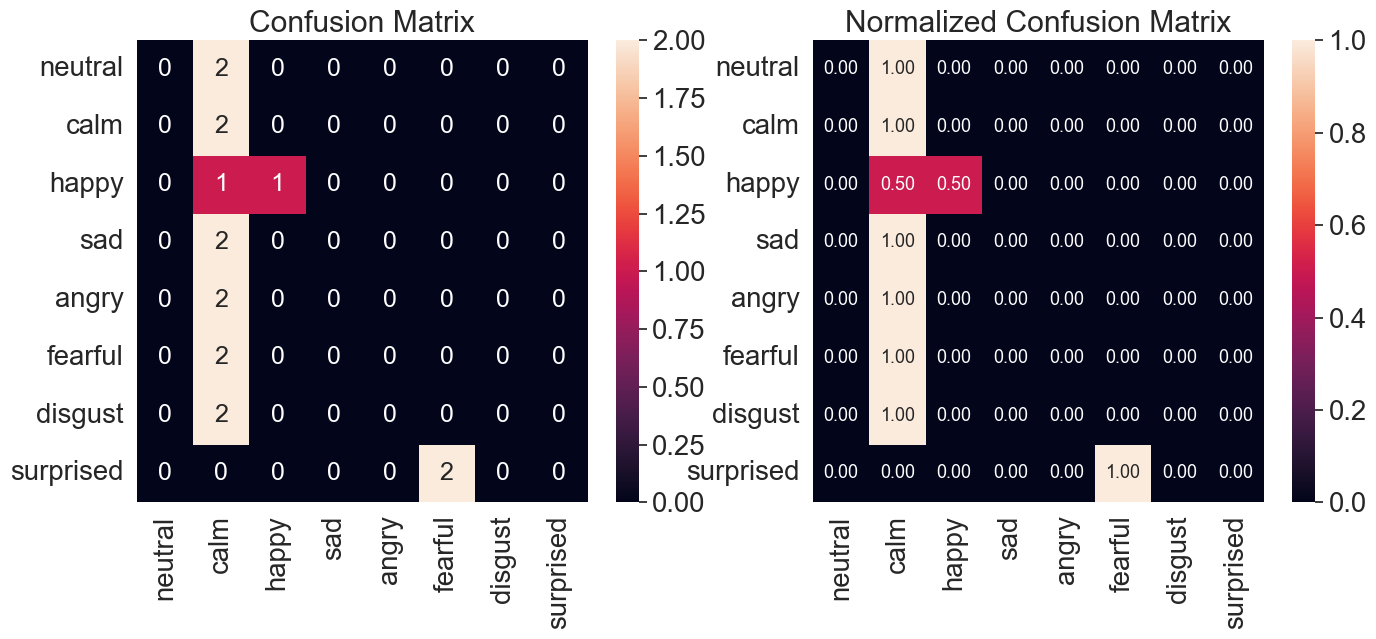

ravdess standard scaled 


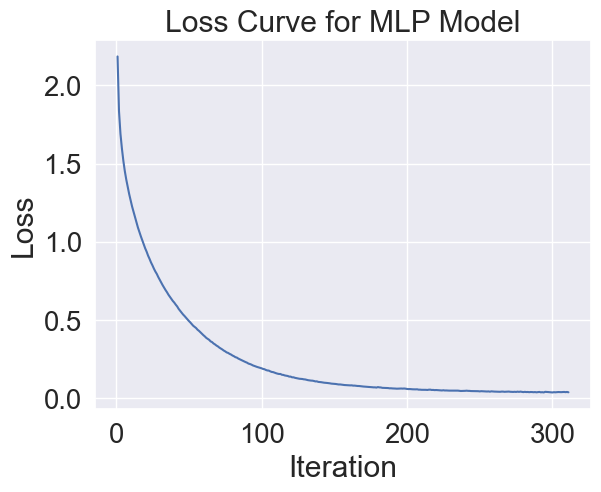

---------------------------------- training set:
Accuracy =  99.739%
Precision =  99.748%
Recall =  99.750%
F-score =  99.7%
----------------------------------------
Best performing emotion:  NEUTRAL (100.00% accuracy)
Worst performing emotion: SURPRISED (99.31% accuracy)
----------------------------------------


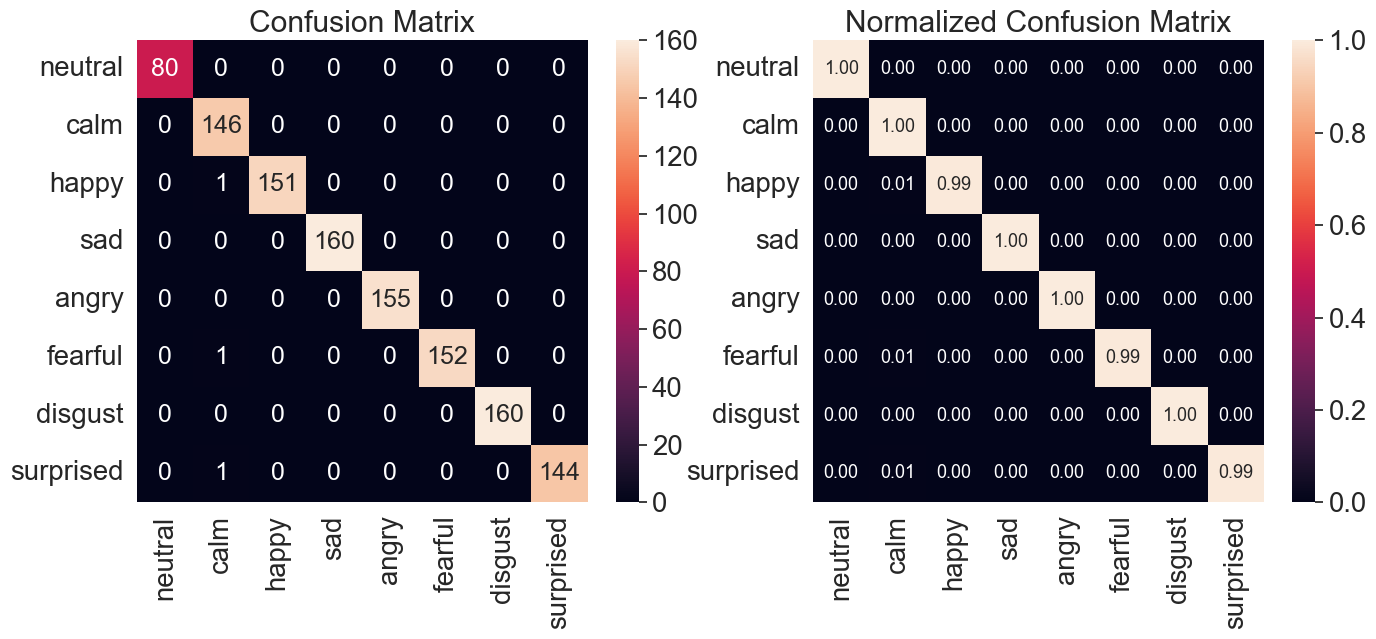

---------------------------------- test set:
Accuracy =  69.792%
Precision =  69.339%
Recall =  69.893%
F-score =  69.2%
----------------------------------------
Best performing emotion:  CALM (86.96% accuracy)
Worst performing emotion: FEARFUL (56.41% accuracy)
----------------------------------------


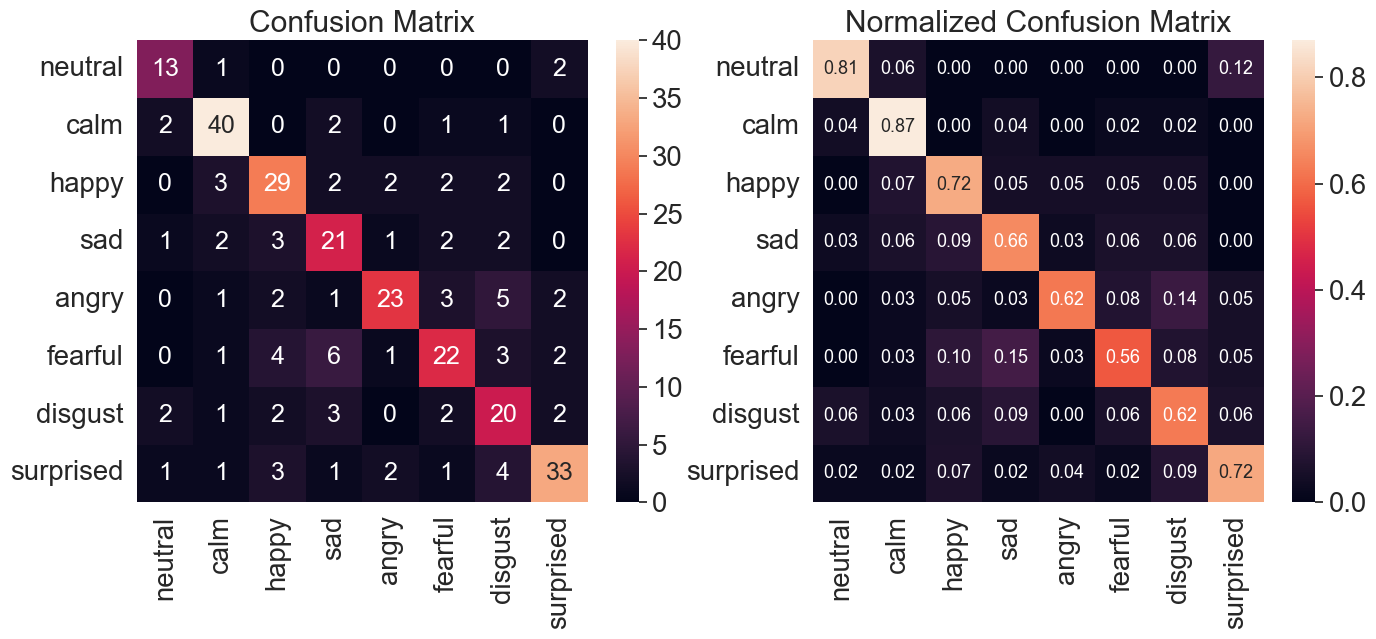

---------------------------------- tigers set:
Accuracy =  37.500%
Precision =  41.667%
Recall =  37.500%
F-score =  36.2%
----------------------------------------
Best performing emotion:  ANGRY (100.00% accuracy)
Worst performing emotion: NEUTRAL (0.00% accuracy)
----------------------------------------


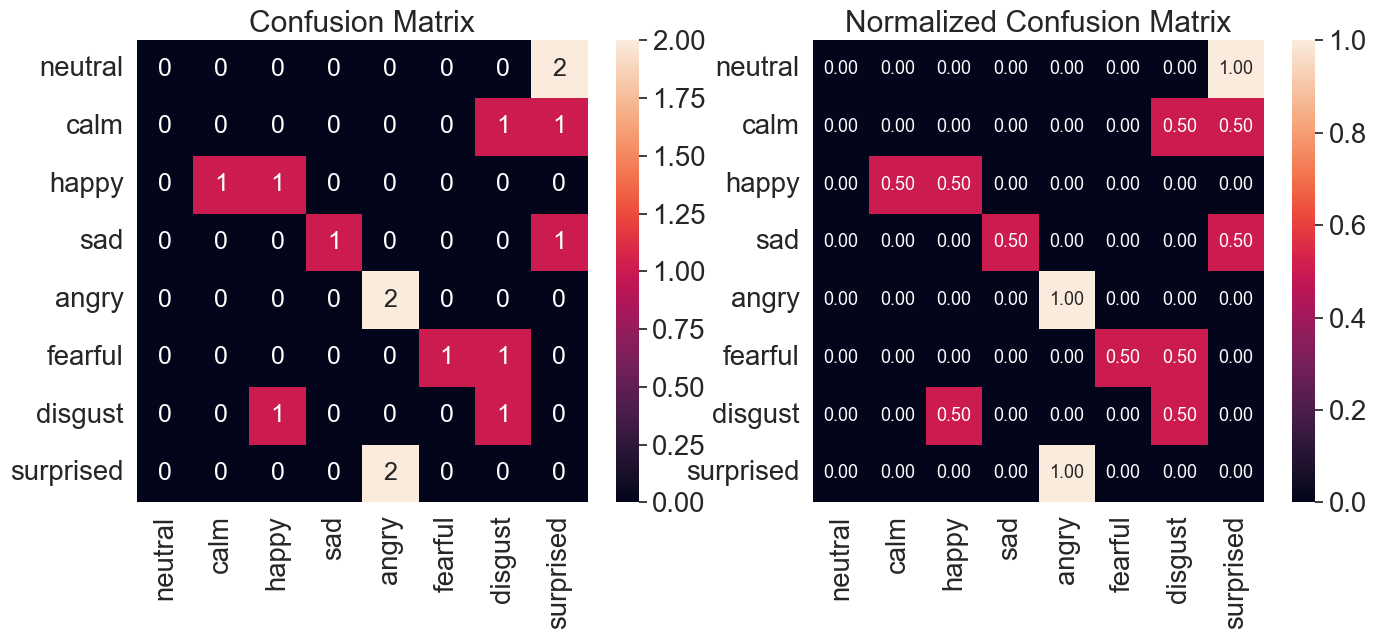

ravdess minmax scaled 


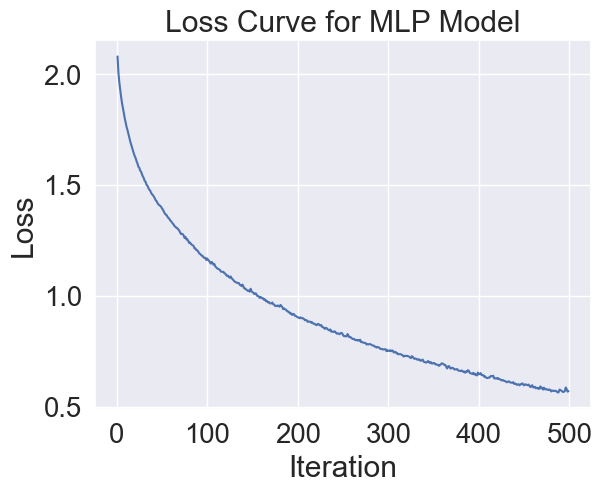

---------------------------------- training set:
Accuracy =  85.491%
Precision =  84.834%
Recall =  84.019%
F-score =  84.3%
----------------------------------------
Best performing emotion:  ANGRY (92.90% accuracy)
Worst performing emotion: NEUTRAL (60.00% accuracy)
----------------------------------------


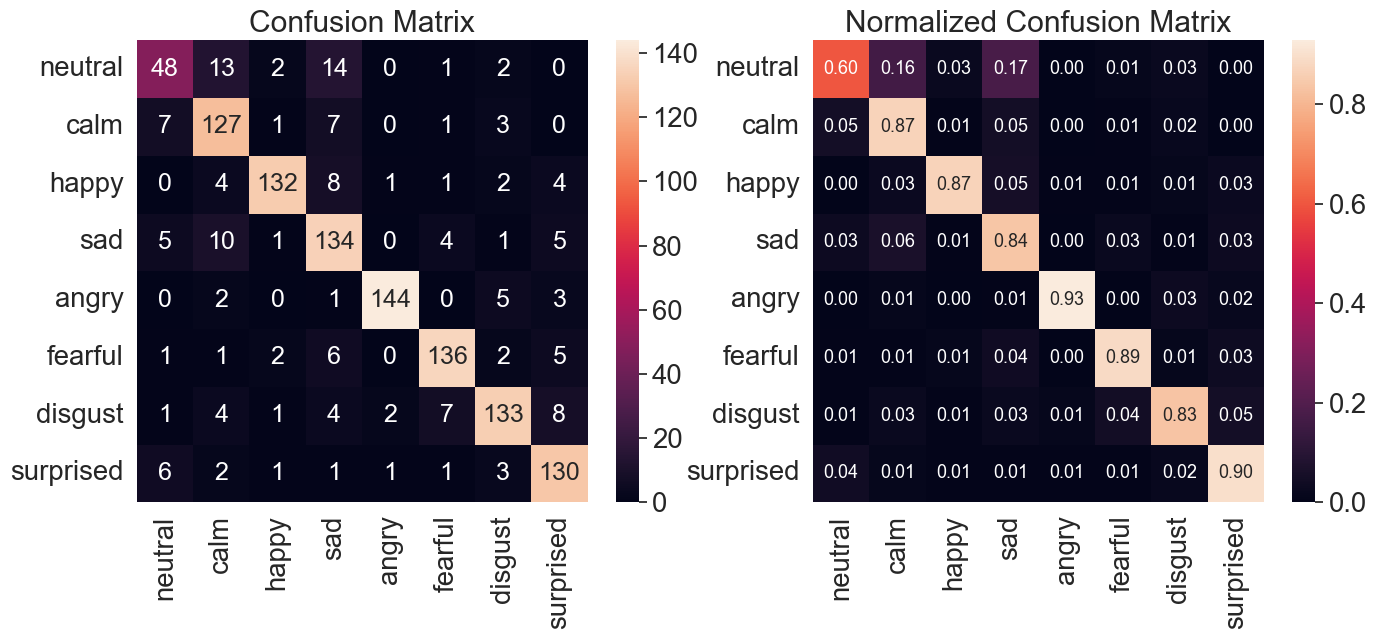

---------------------------------- test set:
Accuracy =  62.847%
Precision =  62.276%
Recall =  62.006%
F-score =  61.8%
----------------------------------------
Best performing emotion:  SURPRISED (71.74% accuracy)
Worst performing emotion: HAPPY (52.50% accuracy)
----------------------------------------


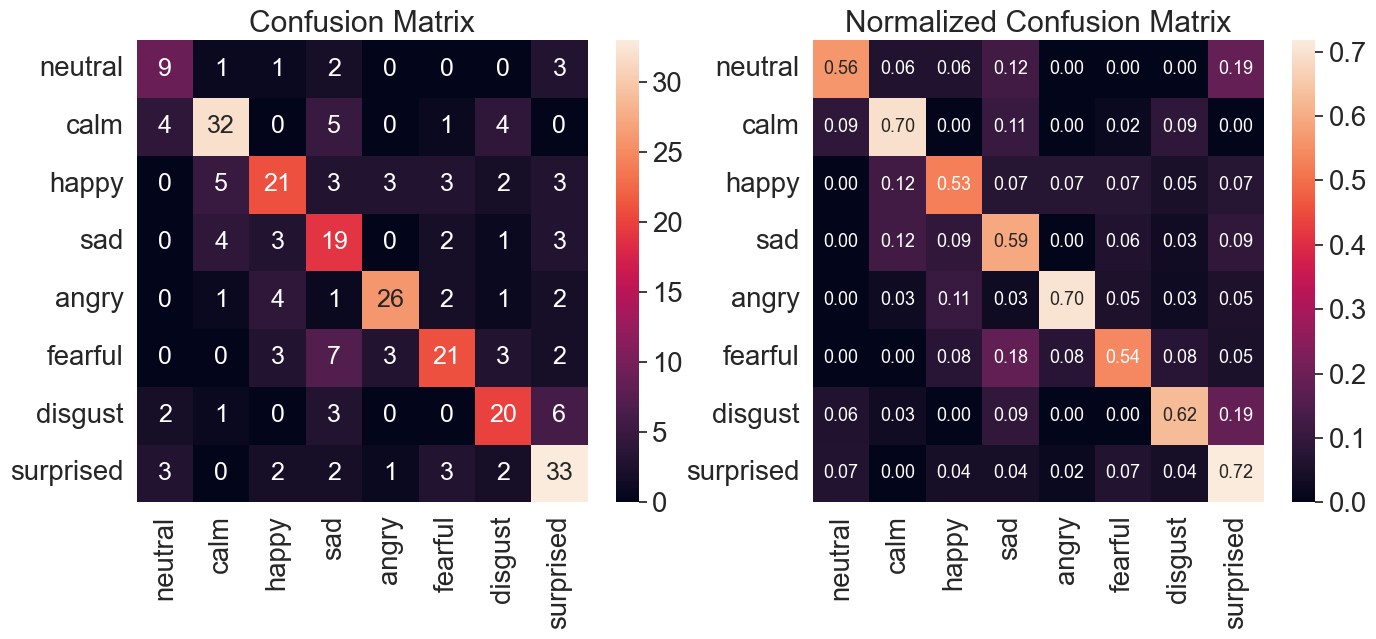

---------------------------------- tigers set:
Accuracy =  18.750%
Precision =  15.278%
Recall =  18.750%
F-score =  12.9%
----------------------------------------
Best performing emotion:  ANGRY (100.00% accuracy)
Worst performing emotion: NEUTRAL (0.00% accuracy)
----------------------------------------


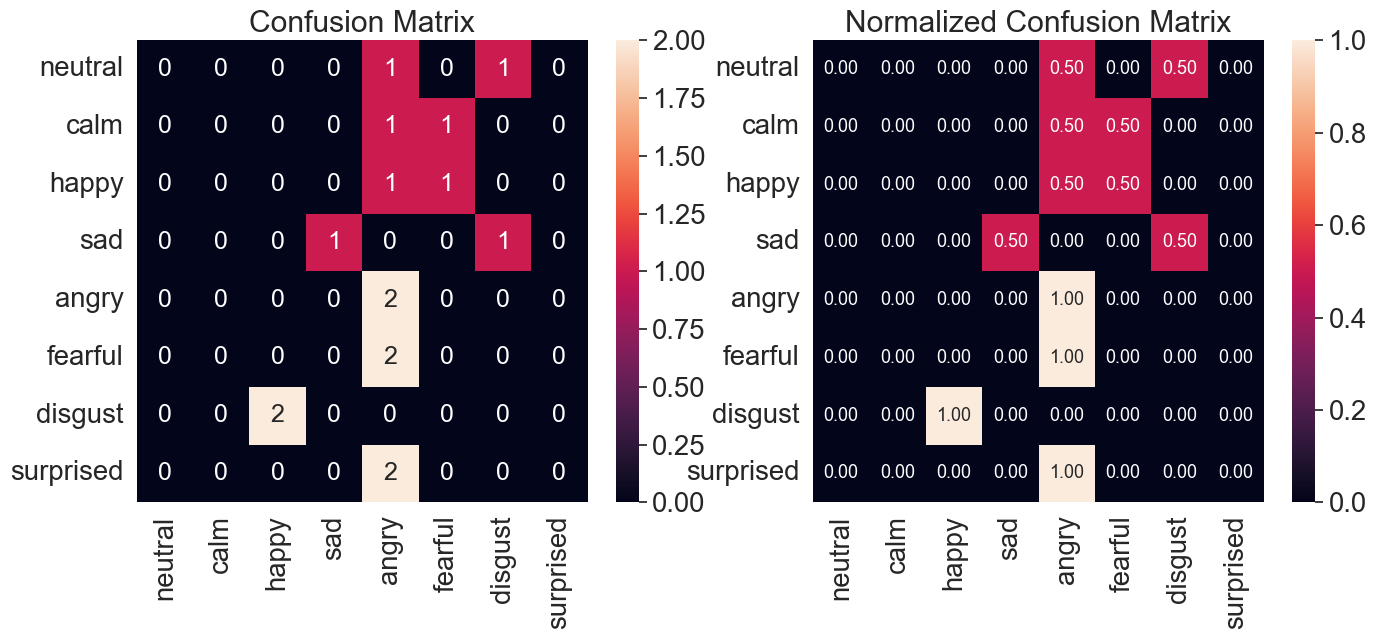

In [46]:

def train_and_test(features_train, emotions_train, features_test, emotions_test, tiger_features, tiger_emotions) :
  # In the final model, we can use the whole training dataset
  model.fit(features_train, emotions_train)

  plot_loss_curve(model)

  print('---------------------------------- training set:')

  compute_scores(model, features_train, emotions_train)

  generate_confusion_matrix(model, features_train, emotions_train)

  print('---------------------------------- test set:')

  compute_scores(model, features_test, emotions_test)

  generate_confusion_matrix(model, features_test, emotions_test)

  print('---------------------------------- tigers set:')

  compute_scores(model, tiger_features, tiger_emotions)

  generate_confusion_matrix(model, tiger_features, tiger_emotions)

def plot_loss_curve(model) :
  plt.figure()
  plt.plot([num for num in range(1,model.n_iter_ +1)], model.loss_curve_)
  plt.title('Loss Curve for MLP Model')
  plt.ylabel('Loss')
  plt.xlabel('Iteration')
  plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sn # I like seaborn's confusion matrix over sklearn's default

def generate_confusion_matrix(model, features_test, emotions_test):
    # get predictions on test set
    test_emotion_predictions = model.predict(features_test)
    test_emotion_groundtruth = emotions_test

    # set labels for matrix axes from emotions
    emotion_list = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

    # build confusion matrix and normalized confusion matrix
    conf_matrix = confusion_matrix(test_emotion_groundtruth, test_emotion_predictions, labels=emotion_list)
    conf_matrix_norm = confusion_matrix(test_emotion_groundtruth, test_emotion_predictions, normalize='true', labels=emotion_list)

    # make a confusion matrix with labels using a DataFrame
    confmatrix_df = pd.DataFrame(conf_matrix, index=emotion_list, columns=emotion_list)
    confmatrix_df_norm = pd.DataFrame(conf_matrix_norm, index=emotion_list, columns=emotion_list)

    # --- NEW CODE: Calculate Best and Worst Performing Classes ---

    # Extract the diagonal of the normalized matrix (True Positive Rate for each class)
    class_accuracies = conf_matrix_norm.diagonal()

    # Get the indices of the maximum and minimum values
    best_index = np.argmax(class_accuracies)
    worst_index = np.argmin(class_accuracies)

    # Map indices back to the emotion names
    best_emotion = emotion_list[best_index]
    worst_emotion = emotion_list[worst_index]

    # Print the results
    print("-" * 40)
    print(f"Best performing emotion:  {best_emotion.upper()} ({class_accuracies[best_index]:.2%} accuracy)")
    print(f"Worst performing emotion: {worst_emotion.upper()} ({class_accuracies[worst_index]:.2%} accuracy)")
    print("-" * 40)

    # -------------------------------------------------------------

    # plot confusion matrices
    plt.figure(figsize=(16,6))
    sn.set(font_scale=1.8) # emotion label and title size

    plt.subplot(1,2,1)
    plt.title('Confusion Matrix')
    sn.heatmap(confmatrix_df, annot=True, annot_kws={"size": 18}, fmt='g') # Added fmt='g' to prevent scientific notation in raw counts

    plt.subplot(1,2,2)
    plt.title('Normalized Confusion Matrix')
    sn.heatmap(confmatrix_df_norm, annot=True, annot_kws={"size": 13}, fmt='.2f')

    plt.show()

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def compute_scores(model, features_test, emotions_test) :

  emotions_pred = model.predict(features_test)
  print(f'Accuracy =  {100*accuracy_score(emotions_test, emotions_pred):.3f}%') #same as model.score(X_test, y_test)
  print(f'Precision =  {100*precision_score(emotions_test, emotions_pred, average="macro"):.3f}%')
  print(f'Recall =  {100*recall_score(emotions_test, emotions_pred, average="macro"):.3f}%')
  print(f'F-score =  {100*f1_score(emotions_test, emotions_pred, average="macro"):.3}%')


print('''==============================================================================
ravdess unscaled
==============================================================================''')

train_and_test(
    ravdess_features_train,
    ravdess_emotions_train,
    ravdess_features_test,
    ravdess_emotions_test,
    tiger_features,
    tiger_emotions
)

print('''==============================================================================
ravdess standard scaled
==============================================================================''')

train_and_test(
    ravdess_features_standard_scaled_train,
    ravdess_emotions_train,
    ravdess_features_standard_scaled_test,
    ravdess_emotions_test,
    tiger_features_standard_scaled,
    tiger_emotions
)

print('''==============================================================================
ravdess minmax scaled
==============================================================================''')

train_and_test(
    ravdess_features_minmax_scaled_train,
    ravdess_emotions_train,
    ravdess_features_minmax_scaled_test,
    ravdess_emotions_test,
    tiger_features_minmax_scaled,
    tiger_emotions
)